### svm_classifier

In this notebook, we attempt to predict nomination-worthy novels using an SVM

In [1]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [2]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyPastNomineeSimilarityScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        # ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])
            ],
)

In [17]:
print(books_tt[list(tag_dataframe.columns)].isna().sum())


tag_                          0
tag_a mix driven              0
tag_adult                     0
tag_adventur                  0
tag_alien                     0
                             ..
tag_weak character develop    0
tag_weird                     0
tag_werewolf                  0
tag_ya                        0
tag_zombi                     0
Length: 120, dtype: int64


We shall use **walk-forward nested time series cross-validation**.

In [18]:
from walkforward_cv import walk_forward

windows = walk_forward(books_tt)


In [51]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

from sklearn.svm import LinearSVC

model = Pipeline([
    ('preprocess', feature_preprocessing),
    ('svc', LinearSVC(penalty='l2', class_weight=None))
])

books_tt['years_since_last_nomination'] = books_tt['years_since_last_nomination'].fillna(99)

In [62]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.metrics import average_precision_score, ndcg_score
from sklearn.metrics import recall_score

cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()

    year = book_val['release_year'].mode().values

    model.fit(book_train[features], book_train['target'])

    ypred = model.predict(book_val[features])

    book_val['predicted'] = ypred


    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = average_precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year, 'f1_score': f1score, 'recall': recall, 'precision': precision})


In [63]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.2756749521414293
STD of f1 score across folds:  0.08169084975992837


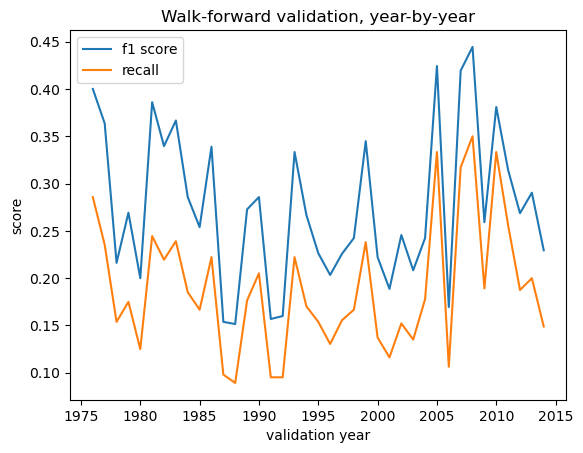

In [64]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

<Axes: >

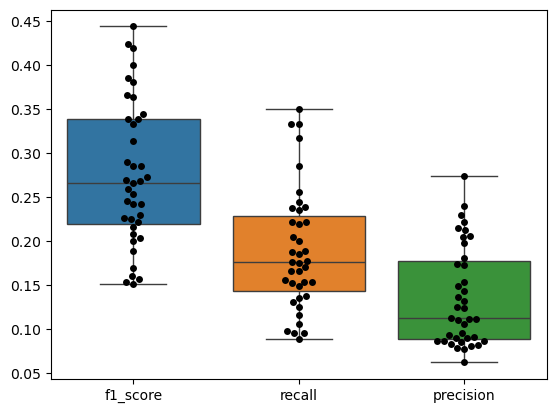

In [65]:
import seaborn as sns


ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')


Let us look at the most important features.

In [66]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

coefs = model.named_steps['svc'].coef_[0] 

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefs)
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                          Feature  Importance
78             tag_similarity__cohort_similiarity    1.170728
79     nominee_similarity__past_winner_similarity    0.885248
64             onehot__first_publisher_zebrabooks    0.626061
57             onehot__first_publisher_simonpulse    0.507999
17          onehot__first_publisher_bantamspectra    0.393856
30               onehot__first_publisher_gollancz    0.354669
45          onehot__first_publisher_pinnaclebooks    0.315722
38           onehot__first_publisher_leisurebooks    0.306996
61                    onehot__first_publisher_tor    0.283135
43                  onehot__first_publisher_orbit    0.268315
35  onehot__first_publisher_hodderchildren'sbooks    0.241119
44              onehot__first_publisher_orbit(us)    0.209669
28              onehot__first_publisher_doubleday    0.200344
27                 onehot__first_publisher_delrey    0.197655
37              onehot__first_publisher_jovebooks    0.196203
23      